<a href="https://colab.research.google.com/github/sagara-pathum/Skit-learn/blob/main/4_Grid_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# from previos note we know that , we need to give different data to test.
# so what we do is we devide our data into 1/3 sections.
# then try for combination of each 2 for training and 1 for testing

# further we know that we need to optimize the n_neighbor valure as well. for that it needed to test to.
# see the video 19:34-- https://www.youtube.com/watch?v=0B5eIE_1vpU&t=6s

# for this we use make a new model architecture
# we call it GridSearchCV object

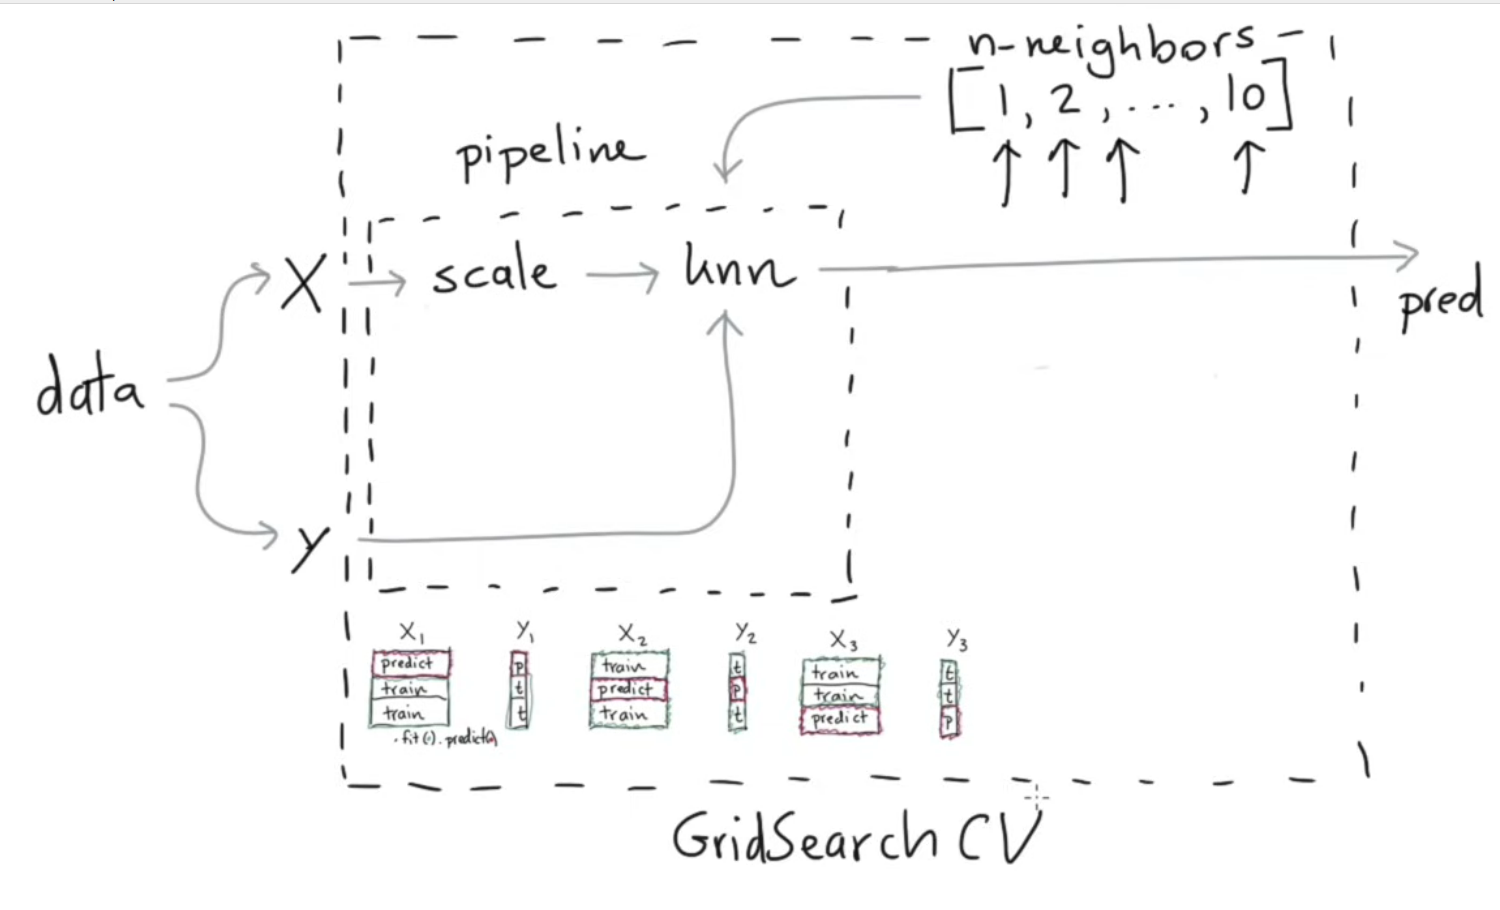

In [1]:
# we can give this a pipeline, grid (for n values here) and cross-validation.

# this object also support .fit() .predict()

In [2]:
# to import this we need to take it from sklearn.model_ selection, name is GridSearchCV

In [3]:
import sklearn

In [5]:
import pandas as pd
import numpy as np


data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8842/79835190.py:6: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor


pipe = Pipeline([("scaler",StandardScaler()),
                 ("model",KNeighborsRegressor())])



In [ ]:
# now lets make GridSearchCV object

# for that we need an estimator (something that cam perform .fit and .predict.  here we can take the pipe),
# parameter grid to check suitable values. but before do that look the what parameters are available to estimator(pipe) using commadn '<estimator>.get_params()'
# then enter the full name of the parameter , and give array of values to be checked

# also define the cross validation. since i devide my set to 3 . i use 3


In [7]:
pipe.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [9]:
from sklearn.model_selection import GridSearchCV

mymodel = GridSearchCV(
    estimator=pipe,
    param_grid={"model__n_neighbors":[1,2,3,4,5,6,7,8,9,10]},
    cv = 3
)

In [11]:
# now we can train
mymodel.fit(X, y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsRegressor())]),
             param_grid={'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [12]:
# now you can see the each training crosss validation grid result using '<object>.cv_results_'

# but it is not readable friendly. so we can make it to datafram and see. to make a data frame we use pandas DataFrame function

mymodel.cv_results_


{'mean_fit_time': array([0.00788196, 0.00719937, 0.010077  , 0.00732231, 0.00765228,
        0.00306098, 0.00661302, 0.00754452, 0.00594791, 0.00306638]),
 'std_fit_time': array([4.32580113e-04, 1.28006362e-03, 2.92940542e-03, 1.28403107e-04,
        2.25991917e-03, 1.14229181e-04, 2.56036846e-03, 2.02791318e-05,
        2.62443288e-03, 1.32870874e-04]),
 'mean_score_time': array([0.00926757, 0.00853046, 0.01099817, 0.01042112, 0.0077974 ,
        0.00526079, 0.00926654, 0.0103608 , 0.00700792, 0.00465163]),
 'std_score_time': array([0.00127435, 0.00024254, 0.00175516, 0.0014555 , 0.00273227,
        0.00123755, 0.00249061, 0.00200281, 0.00271915, 0.00029112]),
 'param_model__n_neighbors': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'params': [{'model__n_neighbors': 1},
  {'model__n_neighbors': 2},
  {'model__n_neighbors': 3},
  {'model__n_n

In [13]:
pd.DataFrame(mymodel.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007882,0.000433,0.009268,0.001274,1,{'model__n_neighbors': 1},0.226933,0.432998,0.127635,0.262522,0.127179,10
1,0.007199,0.001280,0.008530,0.000243,2,{'model__n_neighbors': 2},0.358216,0.409229,0.172294,0.313246,0.101821,9
2,0.010077,0.002929,0.010998,0.001755,3,{'model__n_neighbors': 3},0.413515,0.476651,0.318534,0.402900,0.064986,1
3,0.007322,0.000128,0.010421,0.001456,4,{'model__n_neighbors': 4},0.475349,0.402495,0.273014,0.383619,0.083675,7
4,0.007652,0.002260,0.007797,0.002732,5,{'model__n_neighbors': 5},0.512318,0.347951,0.262590,0.374286,0.103638,8
5,0.003061,0.000114,0.005261,0.001238,6,{'model__n_neighbors': 6},0.533611,0.389504,0.248482,0.390532,0.116406,6
6,0.006613,0.002560,0.009267,0.002491,7,{'model__n_neighbors': 7},0.544782,0.385199,0.243668,0.391216,0.123003,5
7,0.007545,0.000020,0.010361,0.002003,8,{'model__n_neighbors': 8},0.589644,0.394650,0.209714,0.398003,0.155124,2
8,0.005948,0.002624,0.007008,0.002719,9,{'model__n_neighbors': 9},0.590352,0.407556,0.185253,0.394387,0.165643,3
9,0.003066,0.000133,0.004652,0.000291,10,{'model__n_neighbors': 10},0.616510,0.395077,0.164023,0.391870,0.184741,4


In [14]:
#### NOTE this procedure is the most common and standard way using scikit learn. so remember the steps